<a href="https://colab.research.google.com/github/faisu6339-glitch/Data-Strucure-with-Python/blob/main/Bubble_Sort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bubble Sort Algorithm

Bubble Sort is a simple comparison-based sorting algorithm. It repeatedly steps through the list, compares adjacent elements and swaps them if they are in the wrong order. The pass through the list is repeated until no swaps are needed, which indicates that the list is sorted.

Here's how it works in detail:

1.  **Comparison and Swapping**: Starting from the first element, it compares the current element with the next element.
    *   If the current element is greater than the next element, they are swapped.
    *   If they are not, the algorithm moves to the next pair.
2.  **Pass Repetition**: This process continues until the end of the list is reached. After one pass, the largest (or smallest, depending on the sorting order) unsorted element "bubbles up" to its correct position at the end of the unsorted portion of the list.
3.  **Optimization**: In each subsequent pass, the algorithm needs to compare one less element, because the last elements are already sorted and in their correct positions.
4.  **Termination**: The algorithm terminates when a full pass through the list is made without any swaps. This indicates that the list is fully sorted.

**Analogy**: Think of bubbles in a glass of soda. The lighter bubbles (smaller elements) rise to the top, while the heavier ones (larger elements) sink to the bottom. Similarly, in Bubble Sort, elements "bubble up" to their correct sorted positions.

**Example Walkthrough (Ascending Order)**:
Let's sort the array `[5, 1, 4, 2, 8]`:

**First Pass:**
*   (5, 1) -> Swap -> `[1, 5, 4, 2, 8]`
*   (5, 4) -> Swap -> `[1, 4, 5, 2, 8]`
*   (5, 2) -> Swap -> `[1, 4, 2, 5, 8]`
*   (5, 8) -> No Swap -> `[1, 4, 2, 5, 8]`
After first pass, `8` is in its correct place. The largest element `8` has 'bubbled' to the end.

**Second Pass (now we only need to compare up to the 4th element):**
*   (1, 4) -> No Swap -> `[1, 4, 2, 5, 8]`
*   (4, 2) -> Swap -> `[1, 2, 4, 5, 8]`
*   (4, 5) -> No Swap -> `[1, 2, 4, 5, 8]`
After second pass, `5` is in its correct place.

**Third Pass (now we only need to compare up to the 3rd element):**
*   (1, 2) -> No Swap -> `[1, 2, 4, 5, 8]`
*   (2, 4) -> No Swap -> `[1, 2, 4, 5, 8]`
After third pass, `4` is in its correct place.

**Fourth Pass (now we only need to compare up to the 2nd element):**
*   (1, 2) -> No Swap -> `[1, 2, 4, 5, 8]`

No swaps occurred in the fourth pass, so the array is sorted.

**Characteristics:**
*   **Time Complexity**:
    *   **Worst-case and Average-case**: O(n^2) - This happens when the array is in reverse order or randomly ordered, requiring many swaps and comparisons.
    *   **Best-case**: O(n) - This happens when the array is already sorted, and only one pass is needed to confirm no swaps are required.
*   **Space Complexity**: O(1) - It's an in-place algorithm, meaning it doesn't require extra space proportional to the input size.
*   **Stability**: Bubble Sort is a stable sorting algorithm, meaning that elements with the same value maintain their relative order in the sorted output.
*   **Adaptivity**: It is adaptive, meaning it takes advantage of an already partially sorted array, requiring fewer passes.

**Advantages:**
*   **Simplicity**: Very easy to understand and implement.
*   **Stability**: Preserves the relative order of equal elements.
*   **Space Efficient**: Requires minimal extra memory.

**Disadvantages:**
*   **Inefficiency**: Very slow for large datasets compared to other sorting algorithms like Quick Sort or Merge Sort, due to its quadratic time complexity.
*   **Many Swaps**: Can involve many unnecessary swaps if the array is not nearly sorted.

**When to Use It?**
Due to its inefficiency, Bubble Sort is rarely used in real-world applications for sorting large datasets. However, it can be useful for:
*   **Educational purposes**: As a simple introduction to sorting algorithms.
*   **Very small datasets**: Where the overhead of more complex algorithms might outweigh the benefits of their better asymptotic complexity.
*   **When the data is nearly sorted**: In such cases, it can perform well (close to O(n)).

In [1]:
def bubble_sort(arr):
    n = len(arr)
    # Traverse through all array elements
    for i in range(n):
        # Last i elements are already in place
        # So we only need to iterate up to n-i-1
        swapped = False # Flag to optimize: if no two elements were swapped
                        # by inner loop, then break
        for j in range(0, n-i-1):
            # Traverse the array from 0 to n-i-1
            # Swap if the element found is greater than the next element
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                swapped = True
        # If no two elements were swapped by inner loop, then break
        if not swapped:
            break
    return arr

# Example usage:
my_list = [64, 34, 25, 12, 22, 11, 90]
sorted_list = bubble_sort(my_list)
print("Sorted array:", sorted_list)

Sorted array: [11, 12, 22, 25, 34, 64, 90]


#Q: Why do we write range(0, n-i-1) instead of range(n) in Bubble Sort?

Answer:

After every pass, the largest unsorted element is placed at the end of the array.
Those elements are already sorted, so comparing them again is unnecessary.
Therefore, the inner loop becomes shorter after each pass (n - i - 1), reducing the number of comparisons and making the algorithm more efficient.

### Visualizing Bubble Sort Steps

To better understand how Bubble Sort works, let's create a visualization that shows the state of the array after each significant step (i.e., after a swap or after a pass completes). We'll modify the `bubble_sort` function to yield the array's state at each step, and then use `matplotlib` to plot these states.

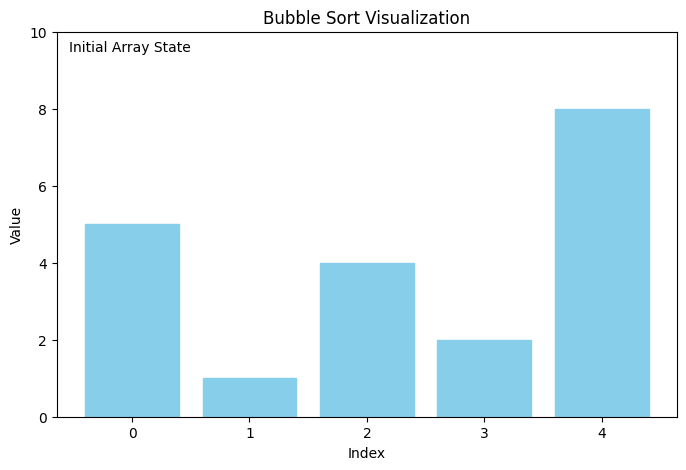

In [3]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def bubble_sort_visualize(arr):
    n = len(arr)
    history = []
    # Store initial state as a dictionary
    history.append({'array': list(arr), 'initial': True})

    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            # Mark elements being compared
            current_state = {'array': list(arr), 'comparing': (j, j+1), 'sorted_until': n-i-1}
            history.append(current_state)

            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
                # Mark elements swapped
                current_state = {'array': list(arr), 'swapped': (j, j+1), 'sorted_until': n-i-1}
                history.append(current_state)

        # Add state after each pass (even if no swap to show the end of a pass)
        history.append({'array': list(arr), 'pass_end': True, 'sorted_until': n-i-1})

        if not swapped:
            # If no two elements were swapped by inner loop, then break
            break

    # Final sorted state
    history.append({'array': list(arr), 'final': True, 'sorted_until': 0})
    return history

# Example usage with visualization enabled
my_list_for_viz = [5, 1, 4, 2, 8]
steps = bubble_sort_visualize(my_list_for_viz)

# Set up the figure and axis for plotting
fig, ax = plt.subplots(figsize=(8, 5))
bar_container = ax.bar(range(len(my_list_for_viz)), steps[0]['array'], color='skyblue')
text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

def update(frame):
    arr_state = frame['array']

    # Update bar heights
    for i, height in enumerate(arr_state):
        bar_container[i].set_height(height)
        bar_container[i].set_color('skyblue') # Reset color

    # Highlight elements based on action
    if 'comparing' in frame:
        j1, j2 = frame['comparing']
        bar_container[j1].set_color('orange')
        bar_container[j2].set_color('orange')
        text.set_text(f'Comparing elements at index {j1} and {j2}')
    elif 'swapped' in frame:
        j1, j2 = frame['swapped']
        bar_container[j1].set_color('red')
        bar_container[j2].set_color('red')
        text.set_text(f'Swapped elements at index {j1} and {j2}')
    elif 'pass_end' in frame:
        text.set_text(f'End of a pass. Sorted elements up to index {frame['sorted_until']}.')
    elif 'final' in frame:
        for bar in bar_container:
            bar.set_color('green')
        text.set_text('Array sorted!')
    elif 'initial' in frame: # Correctly handle the initial state
        text.set_text('Initial Array State')

    # Highlight already sorted part (if any)
    if 'sorted_until' in frame:
        for i in range(frame['sorted_until'], len(arr_state)):
            bar_container[i].set_color('lightgray')

    ax.set_title('Bubble Sort Visualization')
    ax.set_ylabel('Value')
    ax.set_xticks(range(len(arr_state)))
    ax.set_xlabel('Index')
    ax.set_ylim(0, max(my_list_for_viz) + 2)
    return bar_container.patches

# Create the animation
anim = animation.FuncAnimation(fig, update, frames=steps, blit=False, repeat=False, interval=700)

# To display the animation in Jupyter/Colab notebooks
# You might need to install `imagemagick` or `ffmpeg` for certain formats
HTML(anim.to_jshtml())

#1. Sort Student Marks (Ascending)

In [4]:
def bubble_sort(marks):
    n = len(marks)

    for i in range(n):
        for j in range(n-i-1):
            if marks[j] > marks[j+1]:
                marks[j], marks[j+1] = marks[j+1], marks[j]

    return marks

marks = [78, 95, 62, 88, 45]

print(bubble_sort(marks))

[45, 62, 78, 88, 95]


#2. Sort Student Marks (Descending)

In [5]:
def bubble_sort(marks):
    n = len(marks)

    for i in range(n):
        for j in range(n-i-1):
            if marks[j] < marks[j+1]:
                marks[j], marks[j+1] = marks[j+1], marks[j]

    return marks

marks = [78,95,62,88,45]

print(bubble_sort(marks))

[95, 88, 78, 62, 45]


#Program 3: Sort Employee Names (Ascending)

In [6]:
def bubble_sort(names):
    n = len(names)

    for i in range(n):
        for j in range(n - i - 1):
            if names[j] > names[j + 1]:
                names[j], names[j + 1] = names[j + 1], names[j]

    return names


employees = ["Rahul", "Ankit", "Vijay", "Aman", "Zoya"]

print("Original List:", employees)

sorted_names = bubble_sort(employees)

print("Sorted List:", sorted_names)

Original List: ['Rahul', 'Ankit', 'Vijay', 'Aman', 'Zoya']
Sorted List: ['Aman', 'Ankit', 'Rahul', 'Vijay', 'Zoya']


#Program 4: Employee Names from User Input

In [ ]:
def bubble_sort(names):
    n = len(names)

    for i in range(n):
        for j in range(n - i - 1):
            if names[j] > names[j + 1]:
                names[j], names[j + 1] = names[j + 1], names[j]

    return names


n = int(input("Enter number of employees: "))

employees = []

for i in range(n):
    name = input("Enter employee name: ")
    employees.append(name)

print("Sorted Employee Names:")
print(bubble_sort(employees))

#Program 5: Sort Employee Records by Name

In [8]:
employees = [
    {"id": 101, "name": "Rahul"},
    {"id": 102, "name": "Ankit"},
    {"id": 103, "name": "Vijay"},
    {"id": 104, "name": "Aman"}
]

n = len(employees)

for i in range(n):
    for j in range(n - i - 1):
        if employees[j]["name"] > employees[j + 1]["name"]:
            employees[j], employees[j + 1] = employees[j + 1], employees[j]

print("Employees Sorted by Name")

for emp in employees:
    print(emp)

Employees Sorted by Name
{'id': 104, 'name': 'Aman'}
{'id': 102, 'name': 'Ankit'}
{'id': 101, 'name': 'Rahul'}
{'id': 103, 'name': 'Vijay'}
